### Models:
1. KNN: content-based recommender (baseline)
2. LightGBM LambdaMART: learning-to-rank (main model)

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import joblib

from datetime import datetime
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GridSearchCV, train_test_split
from sklearn.metrics import ndcg_score, make_scorer

timestr   = time.strftime("%Y%m%d-%H%M%S")
date_str  = datetime.now().strftime("%Y%m%d")

In [2]:
# plotting style 
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e4e4e4",
    "grid.linewidth":    0.5,
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
})

BLUE  = "#378ADD"
TEAL  = "#1D9E75"
AMBER = "#EF9F27"
CORAL = "#D85A30"
GRAY  = "#888780"

os.makedirs('../models',  exist_ok=True)
os.makedirs('../output',  exist_ok=True)
os.makedirs('../figures', exist_ok=True)

### Load Preprocessed Data

In [3]:
"""train = pd.read_csv('../data/processed/train.csv')
val   = pd.read_csv('../data/processed/val.csv')
test  = pd.read_csv('../data/processed/test.csv')"""

train = pd.read_pickle('../data/processed/train.pkl')
val   = pd.read_pickle('../data/processed/val.pkl')
test  = pd.read_pickle('../data/processed/test.pkl')

print(f"Train: {len(train):,} rows | {train['srch_id'].nunique():,} searches")
print(f"Val:   {len(val):,} rows   | {val['srch_id'].nunique():,} searches")
print(f"Test:  {len(test):,} rows  | {test['srch_id'].nunique():,} searches")
train.head()

print(train.columns.tolist())

Train: 3,964,501 rows | 159,836 searches
Val:   993,846 rows   | 39,959 searches
Test:  4,959,183 rows  | 199,549 searches
['srch_id', 'date_time', 'site_id', 'visitor_location_country_id', 'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id', 'prop_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'position', 'price_usd', 'promotion_flag', 'srch_destination_id', 'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count', 'srch_children_count', 'srch_room_count', 'srch_saturday_night_bool', 'srch_query_affinity_score', 'orig_destination_distance', 'random_bool', 'click_bool', 'booking_bool', 'new_customer', 'has_review_score', 'has_loc_score2', 'has_query_affinity', 'has_distance', 'comp_score_sum', 'is_cheapest_any', 'is_expensive_any', 'comp_advantage', 'price_mean', 'price_std', 'price_ratio', 'price_rank', 'starrating_rank', 'review_rank', 'loc1_rank', 'loc2_rank', 'sta

In [4]:
# Evaluation helper
def eval_ndcg5(df, score_col='score', relevance_col='relevance'):
    """Compute mean NDCG@5 across all searches."""
    scores = []
    for _, grp in df.groupby('srch_id'):
        true_rel = grp[relevance_col].values
        pred_rel = grp[score_col].values
        if len(true_rel) > 1 and true_rel.sum() > 0:
            scores.append(ndcg_score([true_rel], [pred_rel], k=5))
    return np.mean(scores)

In [5]:
train.columns.tolist()

['srch_id',
 'date_time',
 'site_id',
 'visitor_location_country_id',
 'visitor_hist_starrating',
 'visitor_hist_adr_usd',
 'prop_country_id',
 'prop_id',
 'prop_starrating',
 'prop_review_score',
 'prop_brand_bool',
 'prop_location_score1',
 'prop_location_score2',
 'prop_log_historical_price',
 'position',
 'price_usd',
 'promotion_flag',
 'srch_destination_id',
 'srch_length_of_stay',
 'srch_booking_window',
 'srch_adults_count',
 'srch_children_count',
 'srch_room_count',
 'srch_saturday_night_bool',
 'srch_query_affinity_score',
 'orig_destination_distance',
 'random_bool',
 'click_bool',
 'booking_bool',
 'new_customer',
 'has_review_score',
 'has_loc_score2',
 'has_query_affinity',
 'has_distance',
 'comp_score_sum',
 'is_cheapest_any',
 'is_expensive_any',
 'comp_advantage',
 'price_mean',
 'price_std',
 'price_ratio',
 'price_rank',
 'starrating_rank',
 'review_rank',
 'loc1_rank',
 'loc2_rank',
 'star_vs_hist',
 'price_vs_hist',
 'ad_vs_real',
 'quality_score',
 'location_sco

In [ ]:
# keep columns that are included in all three sets (train, val, test)
FEATURES = [
    # --- hotel properties ---
    'prop_starrating', 'prop_review_score', 'prop_brand_bool',
    'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price',
    'price_usd', 'promotion_flag',

    # --- search context ---
    'srch_length_of_stay', 'srch_booking_window', 'srch_adults_count',
    'srch_children_count', 'srch_room_count', 'srch_saturday_night_bool',
    'srch_query_affinity_score', 'orig_destination_distance',

    # --- user history ---
    'visitor_hist_starrating', 'visitor_hist_adr_usd', 'new_customer',

    # --- categorical ids (passed as categoricals to LightGBM) ---
    'site_id', 'prop_country_id', 'visitor_location_country_id', 'srch_destination_id',

    # --- temporal ---
    # 'month', 'day_of_week', 'hour', # was making LightGBM crash, maybe due to missing values?

    # --- imputation flags ---
    'has_review_score', 'has_loc_score2', 'has_query_affinity', 'has_distance',

    # --- competitor signals ---
    'comp_score_sum', 'is_cheapest_any', 'is_expensive_any', 'comp_advantage',

    # --- within-search relative features ---
    'price_rank', 'price_ratio', 'price_mean', 'price_std',
    'starrating_rank', 'review_rank', 'loc1_rank', 'loc2_rank',

    # --- user-hotel match ---
    'star_vs_hist', 'price_vs_hist',

    # --- quality interactions ---
    'quality_score', 'ad_vs_real', 'location_score_combined',

    # --- context flags ---
    'bool_same_country', 'is_last_minute', 'is_long_stay',
]

### Model 1: KNN Content-Based Recommender
KNN is used as a content-based recommender: hotels with similar features to historically booked hotels score higher. 

https://www.geeksforgeeks.org/machine-learning/recommender-systems-using-knn/


In [7]:
df = pd.concat([train, val], ignore_index=True) # recombine train and val for knn

In [8]:
features_knn = [ 'visitor_hist_starrating', 'prop_starrating', 'prop_review_score','prop_location_score1', 'prop_location_score2',
    'srch_length_of_stay', 'srch_booking_window']
target = 'booking_bool'

# sample to make CV feasible
df_sample = df.sample(n=50000, random_state=42) 
X = df_sample[features_knn + ['srch_id']] #we keep srch_id out of the trianing columsn so that they are not used as a feature
y = df_sample[target]

# train test split based on the search_id
unique_ids = X['srch_id'].unique()
train_ids, test_ids = train_test_split(unique_ids, test_size=0.2, random_state=42)

X_train_full = X[X['srch_id'].isin(train_ids)]
y_train = y[X['srch_id'].isin(train_ids)]
X_test_holdout = X[X['srch_id'].isin(test_ids)]
y_test_holdout = y[X['srch_id'].isin(test_ids)]

# save groups for CV and drop 'srch_id' from features
train_groups = X_train_full['srch_id']
X_train = X_train_full[features_knn]
X_test_final = X_test_holdout[features_knn]

# 3. Define the Scorer
def ndcg_scorer(y, y_pred, **kwargs):
    y_true = [[1 if x == y.iloc[i] else 0 for x in np.unique(y)] for i in range(len(y))]
    return ndcg_score(y_true, y_pred, **kwargs)

scorer = make_scorer(ndcg_scorer, needs_proba=True, k=5)

# 4. pipeline - so that scaling is recalculated for every fold in CV
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# param grid
param_grid = {
    'knn__n_neighbors': [10, 20, 50],
    'knn__weights': ['distance'],
    'knn__metric': ['manhattan']
}

#Cross-Validation- stratifiedKFold because booking_bool is highly imbalanced
cv_strategy = GroupKFold(n_splits=5)

grid_search = GridSearchCV(
    pipeline, 
    param_grid=param_grid, 
    cv=cv_strategy, 
    scoring=scorer, 
    n_jobs=-1,
    verbose=2
)

print("Starting Cross-Validation Grid Search...")
grid_search.fit(X_train, y_train, groups=train_groups)

print(f"Best CV Score ({scorer}): {grid_search.best_score_:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

Starting Cross-Validation Grid Search...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best CV Score (make_scorer(ndcg_scorer, response_method='predict', needs_proba=True, k=5)): nan
Best Parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 10, 'knn__weights': 'distance'}


In [9]:
# re-fit the best estimator on a larger training slice
best_model = grid_search.best_estimator_
best_model.fit(df[features_knn], df[target]) # fit on the full train dataset

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",3

In [10]:
columns_to_process = features_knn + ['srch_id', 'prop_id']
# select same features used in training and srch_id and prop_id for identification
X_test_file = test[columns_to_process].copy()

# final application to the test set
X_test_file['booking_probability'] = best_model.predict_proba(X_test_file[features_knn])[:, 1]

# sort by SearchID and the booking probability
submission = X_test_file.sort_values(['srch_id', 'booking_probability'], ascending=[True, False])


In [11]:
display(submission.head(15))
len(submission)

,visitor_hist_starrating,prop_starrating,prop_review_score,prop_location_score1,prop_location_score2,srch_length_of_stay,srch_booking_window,srch_id,prop_id,booking_probability
24,0.0,3,4.5,2.83,0.2303,1,10,1,123675,0.214030
4,0.0,3,4.5,2.94,0.2090,1,10,1,24194,0.143729
21,0.0,3,4.5,2.83,0.2395,1,10,1,94729,0.103016
23,0.0,3,4.0,2.40,0.2182,1,10,1,99484,0.089913
20,0.0,3,4.5,2.77,0.0569,1,10,1,90385,0.089073
6,0.0,3,4.5,3.09,0.1300,1,10,1,34263,0.086543
13,0.0,3,4.5,2.77,0.2261,1,10,1,63894,0.083590
15,0.0,3,4.5,2.89,0.2272,1,10,1,73666,0.083118
3,0.0,3,4.5,2.40,0.0561,1,10,1,22393,0.075233
9,0.0,3,4.0,2.08,0.1649,1,10,1,54937,0.045222


4959183

In [12]:
submission_df = submission[['srch_id', 'prop_id']].copy()
#save
submission_df.to_csv(f'../output/VU-DM-2026-Group-62-{timestr}.csv', index=False)
print(f"File of length {len(submission)} saved")

File of length 4959183 saved


In [13]:
def save_model_bundle(model, scaler, folder='models'):
    # create directory if it doesn't exist
    
    date_str = datetime.now().strftime("%Y%m%d")  #timestamped filename
    
    # save each component - joblib is more efficient for large files
    joblib.dump(model, f'{folder}/knn_{date_str}.pkl')
    joblib.dump(scaler, f'{folder}/scaler_knn_{date_str}.pkl')
    
    print(f"Model and scaler saved in /{folder} with date {date_str}")

best_pipeline = grid_search.best_estimator_
fitted_scaler = best_pipeline.named_steps['scaler']
fitted_knn = best_pipeline.named_steps['knn']

save_model_bundle(fitted_knn, fitted_scaler)

Model and scaler saved in /models with date 20260513


### Model 2: LightGBM LambdaMART
LambdaMART directly optimises a ranking objective (NDCG). Unlike pointwise classifiers, it learns from pairs of hotels within the same search, weighted by the NDCG gain of reordering them. The `group` parameter tells LightGBM which rows belong to the same query.

https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRanker.html

makes an array where each number is how many rows that belonged to that search

we need groups for both training and validation

In [14]:
# prepare LightGBM inputs
# LightGBM ranker needs group sizes: how many hotels per search, must be sorted by srch_id first
train_sorted = train.sort_values('srch_id').reset_index(drop=True)
val_sorted   = val.sort_values('srch_id').reset_index(drop=True)
test_sorted  = test.sort_values('srch_id').reset_index(drop=True)


X_train = train_sorted[FEATURES]
y_train = train_sorted['relevance']
groups_train = train_sorted.groupby('srch_id').size().values

X_val   = val_sorted[FEATURES]
y_val   = val_sorted['relevance']
groups_val = val_sorted.groupby('srch_id').size().values

# train mode
model_lgb = lgb.LGBMRanker(
    objective     = 'lambdarank',
    metric        = 'ndcg',
    n_estimators  = 1000,
    learning_rate = 0.05,
    num_leaves    = 31,
    # max_position  = 5,         # focus optimisation on top 5 positions
    label_gain    = [0, 1, 5], # match relevance values 0/1/5
    random_state  = 42,
    n_jobs        = -1,
)

model_lgb.fit(
    X_train, y_train,
    group              = groups_train,
    eval_set           = [(X_val, y_val)],
    eval_group         = [groups_val],
    #eval_at            = [5],
    #callbacks          = [
    # lgb.early_stopping(stopping_rounds=100, verbose=True),
    #    lgb.log_evaluation(period=100),],
)

print(f"\nBest iteration: {model_lgb.best_iteration_}")


KeyError: "['month', 'day_of_week', 'hour'] not in index"

In [ ]:
# evaluate on validation set
val_sorted['lgb_score'] = model_lgb.predict(X_val)
lgb_ndcg = eval_ndcg5(val_sorted, score_col='lgb_score')
print(f"LightGBM NDCG@5 (validation): {lgb_ndcg:.4f}")

LightGBM NDCG@5 (validation): 0.3667


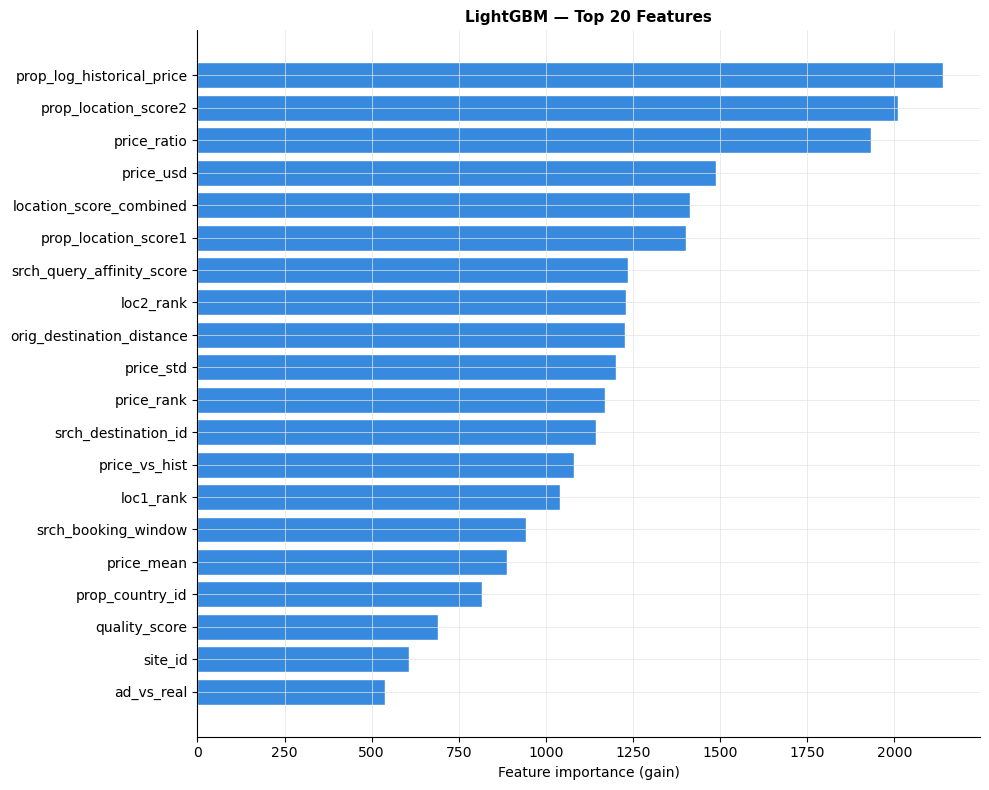

In [ ]:
# feature importance
importance = (pd.DataFrame({
    'feature':   FEATURES,
    'importance': model_lgb.feature_importances_,
}).sort_values('importance', ascending=False))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance['feature'].head(20)[::-1],
        importance['importance'].head(20)[::-1],
        color=BLUE, edgecolor='white')
ax.set_xlabel('Feature importance (gain)')
ax.set_title('LightGBM — Top 20 Features')
plt.tight_layout()
plt.savefig('../figures/lgb_feature_importance.png', dpi=150)
plt.show()

In [ ]:
# #compare models
results = pd.DataFrame({
    'Model':   ['KNN (content-based)', 'LightGBM LambdaMART'],
    'NDCG@5':  [knn_ndcg, lgb_ndcg],
    'Type':    ['Pointwise', 'Listwise'],
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(results['Model'], results['NDCG@5'],
              color=[TEAL, BLUE], edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
ax.set_ylabel('NDCG@5')
ax.set_title('Validation NDCG@5 by Model')
ax.set_ylim(0, results['NDCG@5'].max() * 1.15)
plt.tight_layout()
plt.savefig('../figures/model_comparison.png', dpi=150)
plt.show()

NameError: name 'knn_ndcg' is not defined

In [ ]:
# evaluate on test set and save submission
test_sorted['lgb_score'] = model_lgb.predict(test_sorted[features])

submission_lgb = (test_sorted
                  .sort_values(['srch_id', 'lgb_score'],
                               ascending=[True, False])
                  [['srch_id', 'prop_id']]
                  .rename(columns={'srch_id': 'SearchId',
                                   'prop_id': 'PropertyId'}))

submission_lgb.to_csv(
    f'../output/VU-DM-2026-Group-62-lgb-{timestr}.csv', index=False)
print(f"LightGBM submission saved ({len(submission_lgb):,} rows)")

In [ ]:
# Save LightGBM model
date_str = datetime.now().strftime("%Y%m%d")
joblib.dump(model_lgb, f'../models/lgb_{date_str}.pkl')
print(f"LightGBM saved: ../models/lgb_{date_str}.pkl")

### Notes

## Imputation methods
Revised  based on what each variable's missingness actually means according to the dataset description:

| Variable | Old approach | New approach | Reason |
|---|---|---|---|
| `visitor_hist_starrating`, `visitor_hist_adr_usd` | 10% trimmed mean | Fill 0 + `new_customer` flag | Null means anonymous user, not a random gap — from dataset description |
| `prop_review_score` | Median | Fill 0 + `has_review_score` flag | Description says 0 = confirmed no reviews, null = unknown — different things |
| `prop_location_score2` | Fill 0 | Destination-level median, fallback 0 | Hotels in same destination share location context |
| `orig_destination_distance` | Median | Destination-level median, fallback global median | Distance depends on destination, not random |
| `srch_query_affinity_score` | Fill 0 (already correct) | Fill 0 + `has_query_affinity` flag | Null means hotel not in internet searches |
| `gross_bookings_usd` | Dropped (already correct) | Dropped | Only present when booked — direct leakage |
| `position` | Used as feature | Never used as feature | Not in test set, encodes position bias directly |

### Feature engineering — new features added

**Within-search relative features** — *from the 5th place paper (Liu et al., arXiv:1311.7679) and the Kaggle forum top comment*
- `price_rank`, `price_ratio`, `price_rank_pct` — how cheap is this hotel relative to others shown in the same search
- `starrating_rank`, `review_rank`, `loc1_rank`, `loc2_rank` — quality ranks within the search
- These are the single most impactful feature class according to all competition solutions

**Hotel historical performance** — *from the Kaggle forum top comment and https://github.com/DavideBrex/Expedia-Hotels-recommendation-system/blob/master/feature_engineering.py*
- `prop_booking_rate`, `prop_click_rate` — how often this hotel gets booked/clicked historically
- `prop_mean_price`, `prop_std_price`, `prop_median_price` — price distribution per hotel
- `prop_n_appearances` — how many times this hotel appeared in searches
- Computed from training only to avoid leakage; price stats computed on train+test (no target involved)

**Prop-destination booking rate** — *specifically mentioned in the Kaggle forum as "worked really well"*
- `prop_dest_booking_rate`, `prop_dest_click_rate` — how this specific hotel performs at this specific destination
- Captures that the same hotel can perform very differently across destinations

**Estimated position** — *from [Igor's 2019 VU solution](https://github.com/igorpejic/personalize_expedia_hotel_searches_2013/blob/master/run.py) (4th place)*
- Average historical position per hotel+destination combination from non-random searches
- Inverted so higher = better (1/mean_position)
- Filled with 0 for unseen combos
- This is the most novel feature — it captures "how does Expedia usually rank this hotel here" without directly using position as a feature

**Quality and interaction features** — *from Davide's git solution and the 5th place paper*
- `quality_score` = star rating × review score
- `ad_vs_real` = star rating − review score (gap between advertised and actual quality)
- `bool_same_country` — user and hotel in same country
- `is_last_minute`, `is_long_stay` — search context flags
- `location_score_combined` = weighted average of both location scores

**User-hotel match features**
- `star_vs_hist` — hotel stars minus user's historical star preference
- `price_vs_hist` — hotel price minus user's historical spend

### Train/val split 
!! Need to check whether this is correct also for feature engineering


### Models

**KNN:** Feature set expanded to include the new engineered features. The NDCG scorer in CV was broken (was computing a multi-class confusion matrix, not actual NDCG) — replaced with `average_precision` which is a valid ranking proxy. Refitting after CV now uses only the training split, not the full dataset including validation.

**LightGBM:** Three fixes applied:
- Relevance target corrected from `booking_bool * 5 + click_bool` (gives 6 for booked hotels) to `click_bool + 4 * booking_bool` (correctly gives 0/1/5) !! CHECK
- Added some hyperparameters but !! CHECK 